# Control Template for AFL Users

- name: 
- date: 
- experiment description (few words): 


The following sell will attempt to create a clients for the various AFL systems. Read the output text to determine which connections were successful and what the client objects are called.

In [1]:
%run afl_notebook_setup.ipy

Set up AFL client for Robot OT2 under variable robot_client
Set up AFL client for Orchestrator under variable orch_client



Set up AFL client for AFL Agent under variable agent_client



Attempting to connect to the AFL tiled server...


# Define Components

This step is done entirely in the web interface. Navigate to the web address of the OT2 Server or use the Andon app. In the left bar (scroll down), you should find a button called "Configure Components". Use this to specify the components used in this study. Note that if you want a component to have volume you **must** specify a density. Otherwise, this component will be treated as a volume-less solute. 

# Define Stocks

In this section we define the various stock solutions that are on the OT2 pipettor deck. We'll define their names, compositions and locations on the deck. We'll use the `robot_client` object created by the notebook_setup script run above. Note how each command is called by using the `enqueue` method of the client. 

The stock specification is highly flexible and currently supports a variety of methods for specifying the composition including masses, volumes, concentrations, mass_fractions, volume_fractions, etc. See below for an example that you can modify. 

! Note: The mass spe

In [ ]:
# Remove any stocks that were previously defined on the robot
robot_client.enqueue(task_name='reset_stocks')


robot_client.enqueue(
    task_name='add_stock',
    solution = dict(
        name='stock_H2O',
        masses={'H2O':'20g'}, 
        location='1A1'
    )
)

robot_client.enqueue(
    task_name='add_stock',
    solution = dict(
        name='stock_HC8',
        masses={'HC8':'20 mg'},
        location='1A2'
    )
)

robot_client.enqueue(
    task_name='add_stock',
    solution = dict(
        name='stock_NaC8',
        masses={'NaC8':'2.3780 g', 'H2O':'18.8605 g'},
        location='1A3'
    )
)


'QD-ddadca7e-2ce0-4d16-be1e-6d5ec1d1055a'

# Make Grid of Target Solutions

The AFL works with the concept of `target` solutions beacuse it is (very easy) to ask it to make a solution that is impossible to make with the currently available stocks. Imagine requesting a solute solution at 100 mg/ml when the stock is at 20 mg/ml. This is a trivial example, but becomes much more complicated in higly multicomponent solutions.

To specify a `target`, we use the same `AFL.mixing.Solution` specification laid out above for the stocks. 

**Warning** The solution specification is flexible, but it is easy to end up with something other than what you specified. The AFL attempts to be noisy about this. For example....

In [ ]:
robot_client.enqueue(task_name='reset_targets')

total_vol = 1200
fill_fraction = 0.8
targets = []
for NaC8_conc in np.linspace(0,100,10):
    for HC8_vol in np.linspace(0,600,10):
        H2O_vol = fill_fraction*total_vol - HC8_vol
        if H2O_vol<0:
            continue
        solution = dict( 
            name=f'NaC8-{NaC8_conc:03.0f}mgml-HC8-{HC8_vol:03.0f}ul',
            volumes = {'H2O': f'{H2O_vol}ul', 'HC8':f'{HC8_vol}ul'},
            concentrations = {'NaC8':f'{NaC8_conc}mg/ml'},
            total_volume = f'{total_vol} ul',
        )
        targets.append(solution)
        
robot_client.enqueue(task_name='add_targets',targets=targets)

'QD-f4af61c4-28c6-4a22-8c1c-3e13a556e85c'

In [ ]:
report = robot_client.enqueue(task_name='balance',return_report=True,interactive=True)['return_val']

In [66]:
balanced =  [s for s in report if s['balanced_target'] is not None]
print(f'{len(balanced)} / {len(report)} targets balanced')

60 / 100 targets balanced


NaC8-056mgml-HC8-400ul
NaC8-078mgml-HC8-133ul
NaC8-022mgml-HC8-067ul


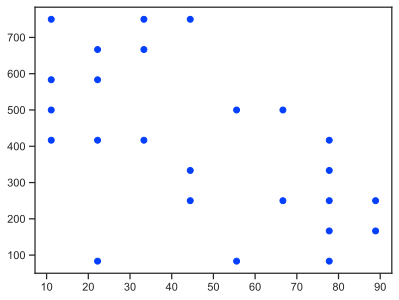

In [67]:
N = 25
grid = []
x = []
y = []
for j,sdict in enumerate(np.random.choice(balanced,size=N,replace=False)):
    
    sample = Solution(**sdict['balanced_target'])
    grid.append(sdict['balanced_target'])
    grid[-1]['name'] = grid[-1]['name'].replace('-balanced','')
    if j<3:
        print(grid[-1]['name'])
    x.append(sample.concentration['NaC8'].to('mg/ml').magnitude)
    y.append(sample['HC8'].volume.to('ul').magnitude)
    
    
    
plt.plot(x,y,ls='None',marker='o')
# plt.gca().set(xlim=(0,0.02),ylim=(-1,1))

    
    

# Configure and Tag Measurement Compaign

In [ ]:
orch_client.set_config(
    data_path='/home/beams/USAXS/Apps/AFL/notebooks/2511/sample_server_data',
    data_tag='NaC8_grid_v2',
    components=['H2O',"NaC8","HC8"],
    AL_components=['H2O',"NaC8","HC8"], #AL = active learning
    concat_dim = 'saxs_sample',
    composition_var_name = 'saxs_comps',
    next_samples_variable='next_samples_saxs',
    prepare_volume='1200ul',
    interactive=False,
)

'QD-734167c9-034b-45d2-8e2a-3611c9994107'

In [ ]:
orch_client.enqueue(task_name='validate_config')

'QD-b002b438-fb4c-4c09-87c6-1bc00ad62204'

# Start Measurement

In [68]:
for sample in grid:
    task = {}
    task['task_name'] = 'process_sample'
    task['sample']  = sample
    task['predict_next'] = False
    task['enqueue_next'] = False
    
    orch.enqueue(interactive=False,**task)

In [20]:
grid

[{'masses': {'H2O': '897.10843373494 mg', 'SiO2': '2.8915662650602614 mg'},
  'name': 'SiO2-0.003-balanced'},
 {'masses': {'H2O': '893.8554216867471 mg', 'SiO2': '6.144578313252985 mg'},
  'name': 'SiO2-0.007-balanced'},
 {'masses': {'H2O': '893.8554216867471 mg', 'SiO2': '6.144578313252985 mg'},
  'name': 'SiO2-0.007-balanced'}]

# Start Active Learning

In [ ]:
task = {}
task['task_name'] = 'process_sample'
task['composition'] = None
task['sample_volume'] = {'value':900,'units':'ul'}
task['fixed_concs'] = {}
task['predict_next'] = True
task['enqueue_next'] = True

orch_client.enqueue(interactive=False,**task)